In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import george,os,pdb,sys,random
from george.kernels import Matern32Kernel,ExpSquaredKernel
import scipy.optimize as op
import scipy.sparse as sp
import scipy.sparse.linalg as spla

In [2]:
#import data

SN_name="SN2010ev"#"SN2007cq"

if SN_name=="SN2010ev":
    z=0.00921
    ra, dec = 156.370792, -39.830889
    #target_snr = 250

file_name="../../DATA/"+SN_name+".fits"


data = fits.open(file_name)
cube = data[1].data   # this is the cube, a (3681 x 341 x 604) matrix with fluxes at different 3681 wavelengths and 308 x 318 spatial pixels ("spaxels")
header = data[1].header # this has information on the data cube
ecube = data[2].data # this is the cube uncertainty (3681 x 341 x 604)
print(np.shape(cube))


x_len=len(cube[0][0])
y_len=len(cube[0])

#  -- following is to the get the wavelength array
CRVAL = float(header["CRVAL3"])
NAXIS = int(header["NAXIS3"])
CDELT = float(header["CD3_3"])
CRPIX = float(header["CRPIX3"])
wave = np.array(CRVAL + CDELT * (np.arange(NAXIS) - CRPIX))

(3681, 341, 604)


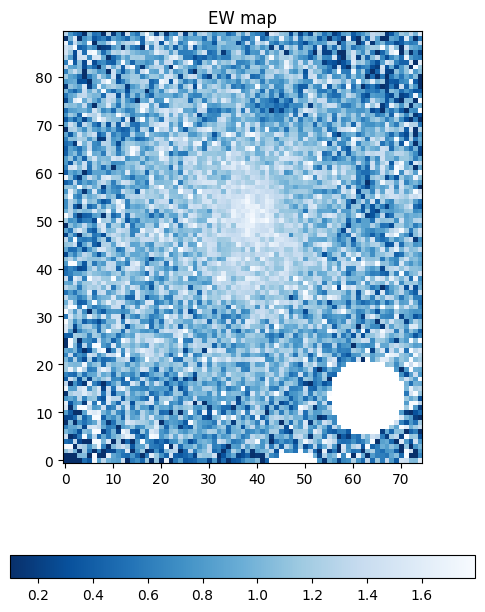

In [3]:
## dimensions
nw,ny,nx = cube.shape

## For now use the average cube as input image
#avg = np.mean(cube,axis=0)

## Use ew-map as input image
ew_map = np.load("ew_map.npy")
ew_err_map = np.load("ew_map_err.npy")
halpha_map = np.load("halpha_map.npy")
halpha_err = np.load("halpha_err.npy")
Av_map = np.load("Av_map.npy")
Av_err_map = np.load("Av_err_map.npy")
cropped_mask = np.load("cropped_mask.npy")

## Plot the ew_map
vmin, vmax = np.nanpercentile(ew_map, [2, 98])
ew_map_clipped = np.clip(ew_map, vmin, vmax)
lo, up = np.nanpercentile(ew_map, 2), np.nanpercentile(ew_map, 98)
plt.figure(figsize=(10, 8))
plt.imshow(ew_map_clipped, cmap='Blues_r', origin='lower', clim=(lo, up))
plt.colorbar(orientation="horizontal", shrink=0.6)
plt.title("EW map")
plt.savefig("EW_map.pdf", bbox_inches='tight')
plt.show()

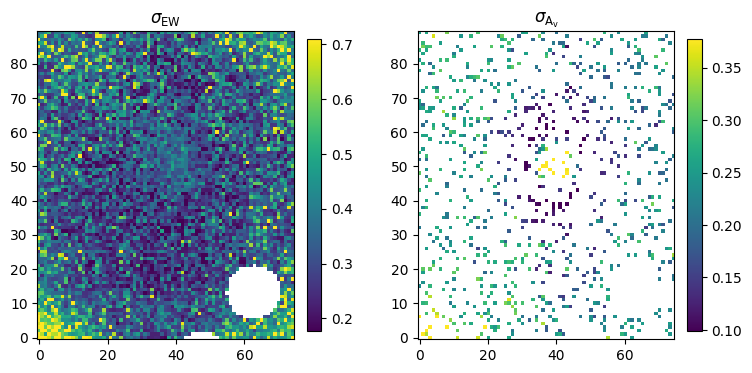

In [4]:
# PLOT UNCERTAINTIES

## Now compare new images
fig, axs = plt.subplots(1, 2, figsize=(9, 4))
lo,up = np.nanpercentile(ew_err_map,2),np.nanpercentile(ew_err_map,98)
im0=axs[0].imshow(ew_err_map,origin='lower', clim=(lo, up))
axs[0].set_title('$\sigma_{\mathrm{EW}}$');
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

lo,up = np.nanpercentile(Av_err_map,2),np.nanpercentile(Av_err_map,98)
im1=axs[1].imshow(Av_err_map,origin='lower', clim=(lo, up))
axs[1].set_title('$\sigma_{\mathrm{A_v}}$');
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

plt.savefig("uncertainties_map.pdf", bbox_inches='tight')

In [5]:
## Function to take out (=nan) a given percentage randomly of the image
def perc_img(img,perc):
    ny, nx = img.shape
    newimg = img.copy()
    for y in range(ny):
        for x in range(nx):
            if float(random.random()) < perc:
                newimg[y, x]=float("nan")
                ####newimg[x][y]=float("nan")
    return newimg

# Function to evaluate the output map
def compute_chi2(mu, data, err_map):
    res = mu - data
    ndata = np.sum(np.isfinite(res) & np.isfinite(err_map))
    chi2 = np.nansum((res / err_map)**2)
    chi2_reduced = chi2 / ndata
    return chi2, chi2_reduced

In [49]:
## Optimize and predict map
def gaussian_process(input_map,err_map=None, mask=None):
    
    ## Get x y and img in format for GP (single array)
    ny,nx = input_map.shape #cube.shape
    x,y = np.linspace(0,nx-1,nx), np.linspace(0,ny-1,ny)
    xv,yv= np.meshgrid(x, y)
    xgp,ygp,navggp = xv.reshape(-1), yv.reshape(-1), input_map.reshape(-1)
    xygp = np.stack((xgp,ygp),axis=1)

    if mask is None:
        mask = np.ones_like(input_map, dtype=bool)
    goodgp = mask.reshape(-1)
    
    ## Kernel for GP
    kernel = Matern32Kernel(0.5, ndim=2)
    gp = george.GP(kernel)
    if err_map is None:
        ## Separate training (non-nan) and test (nan) sets
        wtrain = np.isfinite(navggp) & goodgp
        gp.compute(xygp[wtrain])
    else:
        errgp=err_map.reshape(-1)
        ## Separate training (non-nan) and test (nan) sets
        wtrain = np.isfinite(navggp) & np.isfinite(errgp) & goodgp
        
        gp.compute(xygp[wtrain],yerr=errgp[wtrain])
    
    ## Optimize solution
    # Define the objective function (negative log-likelihood in this case)
    def nll(p):
        gp.set_parameter_vector(p)
        ll = gp.log_likelihood(navggp[wtrain], quiet=True)
        return -ll if np.isfinite(ll) else 1e25
    
    # And the gradient of the objective function
    def grad_nll(p):
        gp.set_parameter_vector(p)
        return -gp.grad_log_likelihood(navggp[wtrain], quiet=True)
    # Print the initial ln-likelihood.
    #print(gp.log_likelihood(navggp[wtrain]))
    
    # Run the optimization routine.
    p0 = gp.get_parameter_vector()
    results = op.minimize(nll, p0, jac=grad_nll, method="L-BFGS-B")

    # Update the kernel and print the final log-likelihood.
    gp.set_parameter_vector(results.x)
    #print(gp.log_likelihood(navggp[wtrain]))
    
    ## Now predict
    #mugp, vargp = gp.predict(navggp[wtrain], xygp, return_var=True)
    
    ## Now predict, only at pixels we actually want
    wpredict = goodgp.copy()
    mu_valid, var_valid = gp.predict(navggp[wtrain], xygp[wpredict], return_var=True)

    ## Reassemble full image, leaving excluded pixels as NaN
    mugp = np.full(ny * nx, np.nan)
    vargp = np.full(ny * nx, np.nan)
    mugp[wpredict] = mu_valid
    vargp[wpredict] = var_valid
    
    ## Revert to image dimension
    mu,var = mugp.reshape(ny,nx),vargp.reshape(ny,nx)
    
    return mu,var

In [50]:
## Obtain an image with certain percentage for EW
perc = 0.4
navg = perc_img(ew_map,perc)
mu_ew,var_ew = gaussian_process(navg,ew_err_map,mask=cropped_mask)

#chi2_ew, chi2_reduced_ew = compute_chi2(mu_ew, ew_map, ew_err_map)
#print("EW: chi2 is", chi2_ew, " reduced chi2 is", chi2_reduced_ew)

memso que acima mas separado em 2 imagens

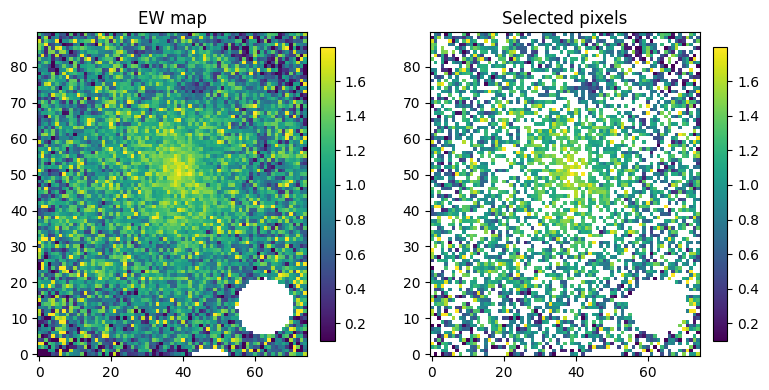

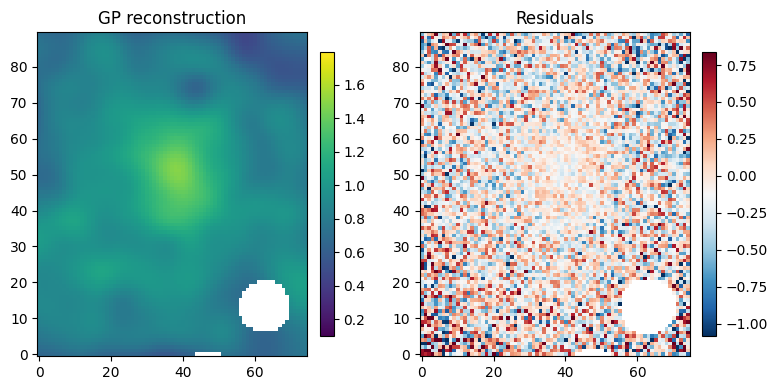

In [52]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
vmin = np.nanpercentile(ew_map, 2)
vmax = np.nanpercentile(ew_map, 98)
im0 = axs[0].imshow(ew_map, origin='lower', vmin=vmin, vmax=vmax)
axs[0].set_title('EW map')
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

im1 = axs[1].imshow(navg, origin='lower', vmin=vmin, vmax=vmax)
axs[1].set_title('Selected pixels')
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("EW_reconstruction_1.png", dpi=150, bbox_inches='tight')

####
            
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

im2 = axs[0].imshow(mu_ew, origin='lower', vmin=vmin, vmax=vmax)
axs[0].set_title('GP reconstruction')
fig.colorbar(im2, ax=axs[0], fraction=0.046, pad=0.04)

res = (mu_ew - ew_map)
lo, up = np.nanpercentile(res, 1), np.nanpercentile(res, 99)


im3 = axs[1].imshow(res, origin='lower', cmap='RdBu_r', vmin=lo, vmax=up)
axs[1].set_title('Residuals')
fig.colorbar(im3, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("EW_reconstruction_2.png", dpi=150, bbox_inches='tight')

In [53]:
### fazer residuals entre a given percentage xx estimation mu_ew_xx and the true value, navg_xx

# validation pixels
val_mask = np.isfinite(navg)

sq_err = (mu_ew[val_mask] - ew_map[val_mask])

sq_err_map = np.full(navg.shape, np.nan)
sq_err_map[val_mask] = sq_err

print("For a percentage of ",perc)
print(f"\nMean of residuals: {np.mean(sq_err):.3f}")
print(f"Median of residuals: {np.median(sq_err):.3f}")
print(f"Std of residuals: {np.std(sq_err):.3f}")



For a percentage of  0.4

Mean of residuals: -0.085
Median of residuals: -0.083
Std of residuals: 0.375


In [54]:
#***************************************************************

GP reconstruction but for Halpha

In [55]:
## Obtain an image with certain percentage for EW
perc = 0.50
navg = perc_img(halpha_map,perc)
mu_halpha,var_halpha = gaussian_process(navg,halpha_err,mask=cropped_mask)

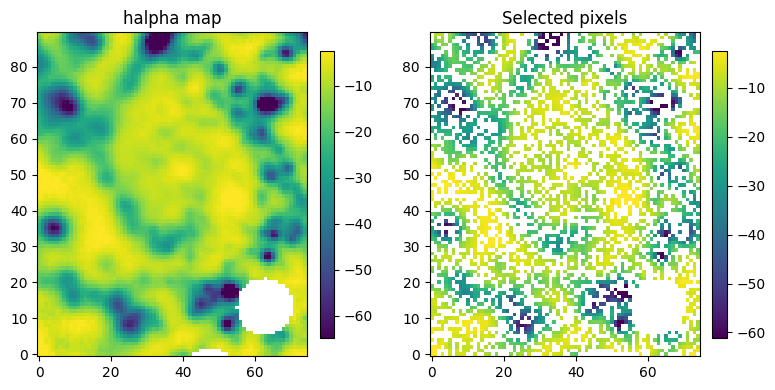

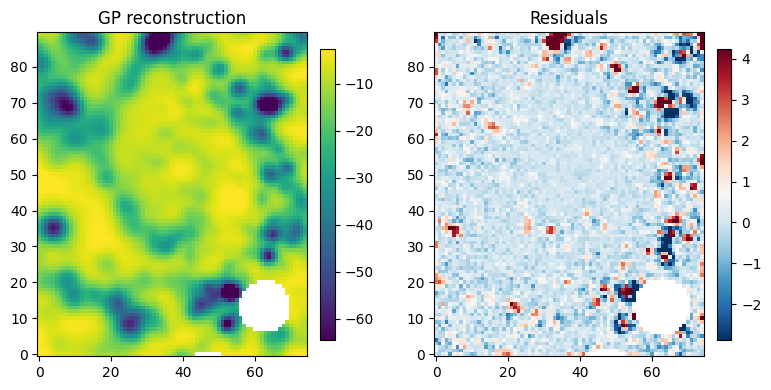

In [56]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

lo, up = np.nanpercentile(halpha_map, 1), np.nanpercentile(halpha_map, 99)
im0 = axs[0].imshow(halpha_map, origin='lower', vmin=lo, vmax=up)
axs[0].set_title('halpha map')
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

lo, up = np.nanpercentile(navg, 1), np.nanpercentile(navg, 99)
im1 = axs[1].imshow(navg, origin='lower', vmin=lo, vmax=up)
axs[1].set_title('Selected pixels')
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("halpha_reconstruction_1.png", dpi=150, bbox_inches='tight')

####
            
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

lo, up = np.nanpercentile(mu_halpha, 1), np.nanpercentile(mu_halpha, 99)
im2 = axs[0].imshow(mu_halpha, origin='lower', vmin=lo, vmax=up)
axs[0].set_title('GP reconstruction')
fig.colorbar(im2, ax=axs[0], fraction=0.046, pad=0.04)

res = (mu_halpha - halpha_map)
lo, up = np.nanpercentile(res, 1), np.nanpercentile(res, 99)


im3 = axs[1].imshow(res, origin='lower', cmap='RdBu_r', vmin=lo, vmax=up)
axs[1].set_title('Residuals')
fig.colorbar(im3, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("halpha_reconstruction_2.png", dpi=150, bbox_inches='tight')

In [57]:
# validation pixels
val_mask = ~np.isfinite(navg)

sq_err = (mu_halpha[val_mask] - halpha_map[val_mask])

sq_err_map = np.full(navg.shape, np.nan)
sq_err_map[val_mask] = sq_err

print(f"Mean of residuals: {np.nanmean(sq_err):.3f}")
print(f"Median of residuals: {np.nanmedian(sq_err):.3f}")
print(f"Std of residuals: {np.nanstd(sq_err):.3f}")

Mean of residuals: 0.120
Median of residuals: 0.003
Std of residuals: 1.531


GP reconstruction for Av

In [63]:
## Obtain an image with certain percentage for Av
perc = 0.5
navg_80 = perc_img(Av_map,perc)
mu_Av_80, var_Av_80 = gaussian_process(navg_80,Av_err_map,mask=cropped_mask)

## Obtain an image with all Av vals
perc = 0.5
navg_100 = perc_img(Av_map,perc)
mu_Av_100, var_Av_100 = gaussian_process(navg_100,Av_err_map,mask=cropped_mask)

In [64]:
#chi2_Av, chi2_reduced_Av = compute_chi2(mu_Av_80, Av_map, Av_err_map)
#print("Av: chi2 is", chi2_Av, " reduced chi2 is", chi2_reduced_Av)

In [65]:
# validation pixels
val_mask = np.isfinite(navg_100) & ~np.isfinite(navg_80)

sq_err = (mu_Av_80[val_mask] - navg_100[val_mask])

sq_err_map = np.full(navg_100.shape, np.nan)
sq_err_map[val_mask] = sq_err

print(f"Mean of residuals: {np.mean(sq_err):.3f}")
print(f"Median of residuals: {np.median(sq_err):.3f}")
print(f"Std of residuals: {np.std(sq_err):.3f}")

Mean of residuals: -0.011
Median of residuals: -0.011
Std of residuals: 0.070


In [66]:
## Now compare Av images
"""vmin = np.nanpercentile([Av_map, mu_Av_100], 1)
vmax = np.nanpercentile([Av_map, mu_Av_100], 99)

fig, axs = plt.subplots(1, 5, figsize=(15, 4))

axs[0].imshow(Av_map,origin='lower', vmin=vmin, vmax=vmax)
axs[0].set_title('Av map')

axs[1].imshow(navg_80,origin='lower')#, vmin=vmin, vmax=vmax)
axs[1].set_title('80% of Av map')

axs[2].imshow(mu_Av_80,origin='lower', vmin=vmin, vmax=vmax)
axs[2].set_title('Reconstruction using 50%')

axs[3].imshow(mu_Av_100,origin='lower')#, vmin=vmin, vmax=vmax)
axs[3].set_title('Reconstruction using 100%')

axs[4].imshow(sq_err_map,origin='lower')#, vmin=vmin, vmax=vmax)
axs[4].set_title('Residuals')""";

still av plots but divided in two images

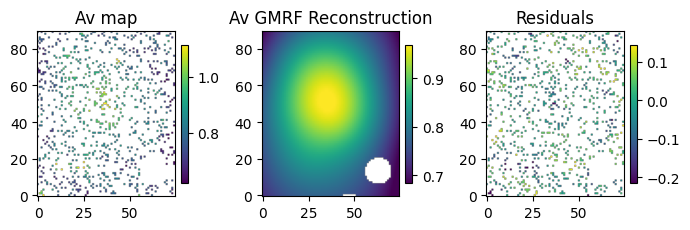

In [67]:
fig, axs = plt.subplots(1, 3, figsize=(7, 4))

lo, up = np.nanpercentile(Av_map, 1), np.nanpercentile(Av_map, 99)

im0 = axs[0].imshow(Av_map, origin='lower',clim=(lo,up))
axs[0].set_title('Av map')
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

"""im1 = axs[1].imshow(navg_80, origin='lower')
axs[1].set_title('80% of Av map')
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

im2 = axs[1].imshow(mu_Av_80, origin='lower')
axs[1].set_title('Reconstruction using 80%')
fig.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)"""

lo, up = np.nanpercentile(mu_Av_100, 1), np.nanpercentile(mu_Av_100, 99)

im3 = axs[1].imshow(mu_Av_100, origin='lower',clim=(lo,up))
axs[1].set_title('Av GMRF Reconstruction')
fig.colorbar(im3, ax=axs[1], fraction=0.046, pad=0.04)

lo, up = np.nanpercentile(sq_err_map, 1), np.nanpercentile(sq_err_map, 99)

res=mu_Av_100-Av_map
im4 = axs[2].imshow(res, origin='lower',clim=(lo,up))
#im4 = axs[2].imshow(sq_err_map, origin='lower',clim=(lo,up))
axs[2].set_title('Residuals')
fig.colorbar(im4, ax=axs[2], fraction=0.046, pad=0.04)


plt.tight_layout()
plt.savefig("Av_reconstruction_1.png", dpi=150, bbox_inches='tight')


#plt.tight_layout()
#plt.savefig("Av_reconstruction_2.png", dpi=150, bbox_inches='tight')

In [152]:
print(np.sum(np.isfinite(navg_80))/(90*75)*100)

7.303703703703704


# GMRF

In [189]:
## Complete a 2D map using a GMRF (graph Laplacian) prior.
"""def gmrf_complete(Av_map, valid_mask=None):
    
    ny, nx = Av_map.shape
    N = ny * nx

    obs_mask = ~np.isnan(Av_map)
    idx = np.arange(N).reshape(ny, nx)

    if valid_mask is None:
        valid_mask = np.ones_like(obs_mask, dtype=bool)

    
    # Build graph Laplacian for a 4-neighbor grid
    rows, cols = [], []
    for i in range(ny):
        for j in range(nx):
            if not valid_mask[i, j]:
                continue
            k = idx[i, j]
            if i + 1 < ny and valid_mask[i+1, j]:
                rows.append(k); cols.append(idx[i+1, j])
            if j + 1 < nx and valid_mask[i, j+1]:
                rows.append(k); cols.append(idx[i, j+1])
                
    rows = np.array(rows); cols = np.array(cols)

    # Build sparse adjacency, then Laplacian Q = D - A
    A = sp.coo_matrix((np.ones(len(rows)), (rows, cols)), shape=(N, N))
    A = A + A.T  # symmetric
    D = sp.diags(np.array(A.sum(axis=1)).flatten())
    Q = (D - A).tocsr()

    # Partition into observed (o) and unobserved (u)
    valid_flat = valid_mask.flatten()
    obs_flat = (obs_mask & valid_mask).flatten()
    u_idx = np.where(valid_flat & ~obs_flat)[0]
    o_idx = np.where(obs_flat)[0]

    Q_uu = Q[u_idx][:, u_idx]
    Q_uo = Q[u_idx][:, o_idx]
    x_o = Av_map.flatten()[o_idx]

    rhs = -Q_uo @ x_o
    x_u = spla.spsolve(Q_uu.tocsc(), rhs)

    result = np.full(N, np.nan)
    result[o_idx] = x_o
    result[u_idx] = x_u
    return result.reshape(ny, nx)"""
def gmrf_complete(Av_map, valid_mask=None, err_map=None):
    
    ny, nx = Av_map.shape
    N = ny * nx
    obs_mask = ~np.isnan(Av_map)
    idx = np.arange(N).reshape(ny, nx)
    if valid_mask is None:
        valid_mask = np.ones_like(obs_mask, dtype=bool)
    
    rows, cols = [], []
    for i in range(ny):
        for j in range(nx):
            if not valid_mask[i, j]:
                continue
            k = idx[i, j]
            if i + 1 < ny and valid_mask[i+1, j]:
                rows.append(k); cols.append(idx[i+1, j])
            if j + 1 < nx and valid_mask[i, j+1]:
                rows.append(k); cols.append(idx[i, j+1])
                
    rows = np.array(rows); cols = np.array(cols)
    A = sp.coo_matrix((np.ones(len(rows)), (rows, cols)), shape=(N, N))
    A = A + A.T
    D = sp.diags(np.array(A.sum(axis=1)).flatten())
    Q = (D - A).tocsr()

    valid_flat = valid_mask.flatten()
    obs_flat = (obs_mask & valid_mask).flatten()
    x_flat = Av_map.flatten()

    if err_map is None:
        u_idx = np.where(valid_flat & ~obs_flat)[0]
        o_idx = np.where(obs_flat)[0]
        Q_uu = Q[u_idx][:, u_idx]
        Q_uo = Q[u_idx][:, o_idx]
        x_o = x_flat[o_idx]
        x_u = spla.spsolve(Q_uu.tocsc(), -Q_uo @ x_o)
        result = np.full(N, np.nan)
        result[o_idx] = x_o
        result[u_idx] = x_u

    else:
        err_flat = err_map.flatten()
        good_obs = obs_flat & valid_flat & np.isfinite(err_flat) & (err_flat > 0)

        precision = np.zeros(N)
        precision[good_obs] = 1.0 / err_flat[good_obs]**2
        Cinv = sp.diags(precision)

        # build rhs safely — only fill in where we have real data
        b = np.zeros(N)
        b[good_obs] = x_flat[good_obs] * precision[good_obs]  # NaN-safe: only index good pixels

        v_idx = np.where(valid_flat)[0]
        M = (Q + Cinv)[v_idx][:, v_idx].tocsc()
        x_v = spla.spsolve(M, b[v_idx])

        result = np.full(N, np.nan)
        result[v_idx] = x_v

    return result.reshape(ny, nx)

EW reconstruction of 50% of spaxels

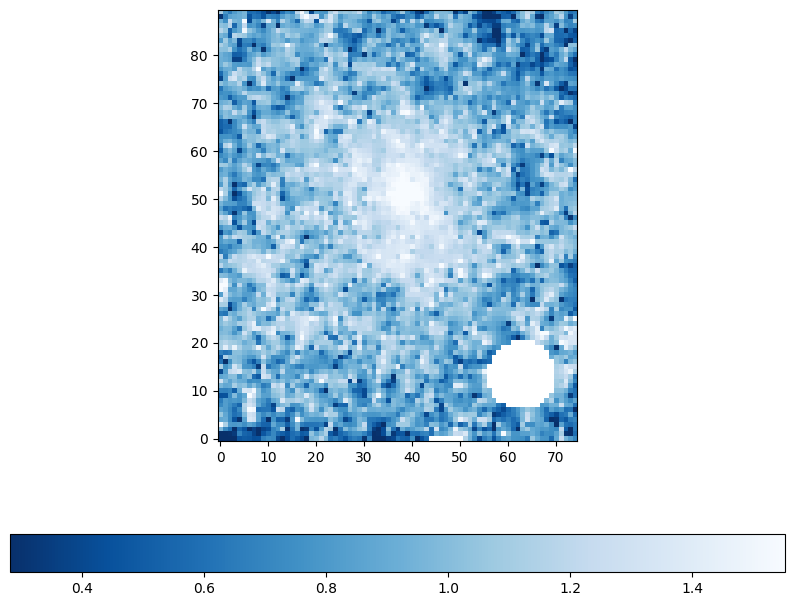

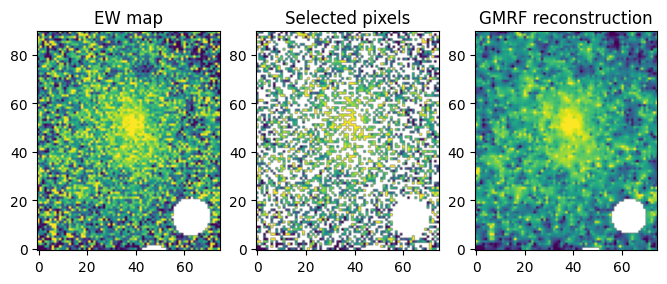

In [193]:
## Obtain an image with certain percentage for EW
perc = 0.5
navg = perc_img(ew_map,perc)

EW_map_complete = gmrf_complete(navg,valid_mask=cropped_mask, err_map=ew_err_map)

## Plot the ew_map
lo, up = np.nanpercentile(EW_map_complete, 1), np.nanpercentile(EW_map_complete, 99)
plt.figure(figsize=(10, 8))
plt.imshow(EW_map_complete, cmap='Blues_r', clim=(lo, up),origin='lower')
plt.colorbar(orientation="horizontal")
plt.show()

## Now compare new images
fig, axs = plt.subplots(1, 3, figsize=(8, 4))
lo,up = np.nanpercentile(EW_map_complete,1),np.nanpercentile(EW_map_complete,99)
axs[0].imshow(ew_map,origin='lower', clim=(lo, up))
axs[0].set_title('EW map');
axs[1].imshow(navg,origin='lower', clim=(lo, up))
axs[1].set_title('Selected pixels');
axs[2].imshow(EW_map_complete, clim=(lo, up),origin='lower')
axs[2].set_title('GMRF reconstruction')


plt.savefig("EW_GMRF_map.pdf", bbox_inches='tight')

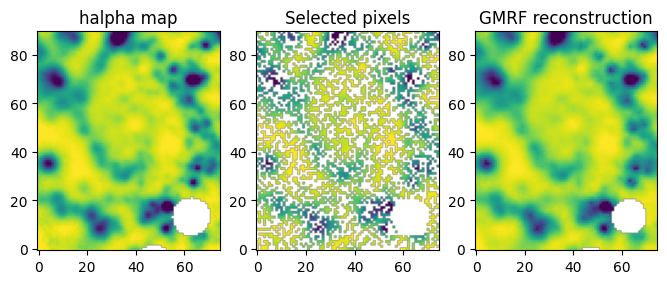

In [199]:
## Obtain an image with certain percentage for EW
perc = 0.5
navg = perc_img(halpha_map,perc)

halpha_map_complete = gmrf_complete(navg,valid_mask=cropped_mask, err_map=halpha_err)

## Plot the ew_map
#lo, up = np.nanpercentile(halpha_map_complete, 1), np.nanpercentile(halpha_map_complete, 99)
#plt.figure(figsize=(10, 8))
#plt.imshow(halpha_map_complete, cmap='Blues_r', clim=(lo, up),origin='lower')
#plt.colorbar(orientation="horizontal")
#plt.show()

## Now compare new images
fig, axs = plt.subplots(1, 3, figsize=(8, 4))
lo,up = np.nanpercentile(halpha_map_complete,1),np.nanpercentile(halpha_map_complete,99)
axs[0].imshow(halpha_map,origin='lower', clim=(lo, up))
axs[0].set_title('halpha map');
axs[1].imshow(navg,origin='lower', clim=(lo, up))
axs[1].set_title('Selected pixels');
axs[2].imshow(halpha_map_complete, clim=(lo, up),origin='lower')
axs[2].set_title('GMRF reconstruction')


plt.savefig("halpha_GMRF_map.pdf", bbox_inches='tight')

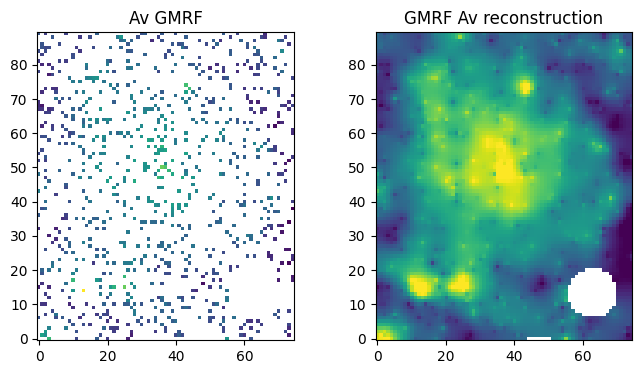

In [195]:
Av_map_complete = gmrf_complete(Av_map, valid_mask=cropped_mask,err_map=Av_err_map)

## Plot the ew_map


#lo, up = np.nanpercentile(Av_map_complete, 1), np.nanpercentile(Av_map_complete, 99)
#plt.figure(figsize=(10, 8))
#plt.imshow(Av_map_complete, cmap='Blues_r', clim=(lo, up),origin='lower')
#plt.colorbar(orientation="horizontal")
#plt.show()

## Now compare new images
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
lo,up = np.nanpercentile(Av_map_complete,1),np.nanpercentile(Av_map_complete,99)
axs[1].imshow(Av_map_complete, clim=(lo, up),origin='lower')
axs[1].set_title('GMRF Av reconstruction')
#axs[1].imshow(ew_map,origin='lower')
#axs[1].set_title('EW map')
axs[0].imshow(Av_map,origin='lower')
axs[0].set_title('Av GMRF');

plt.savefig("Av_GMRF_map.pdf", bbox_inches='tight')

In [ ]:
# validation pixels
val_mask = np.isfinite(navg_100) & ~np.isfinite(navg_80)

sq_err = (mu_Av_80[val_mask] - navg_100[val_mask])**2

sq_err_map = np.full(navg_100.shape, np.nan)
sq_err_map[val_mask] = sq_err

print(f"Mean of residuals: {np.mean(sq_err):.3f}")
print(f"Median of residuals: {np.median(sq_err):.3f}")
print(f"Std of residuals: {np.std(sq_err):.3f}")

## INLA

In [182]:
from pyinla import pyinla

def build_graph_file(nrow, ncol, path="pixels.graph"):
    """4-connectivity neighbor graph over a complete nrow x ncol grid."""
    n = nrow * ncol
    neighbors = {i: [] for i in range(1, n + 1)}

    for r in range(nrow):
        for c in range(ncol):
            i = r * ncol + c + 1

            if c + 1 < ncol:
                j = r * ncol + (c + 1) + 1
                neighbors[i].append(j)
                neighbors[j].append(i)

            if r + 1 < nrow:
                j = (r + 1) * ncol + c + 1
                neighbors[i].append(j)
                neighbors[j].append(i)

    with open(path, "w") as f:
        f.write(f"{n}\n")
        for i in range(1, n + 1):
            nb = sorted(set(neighbors[i]))
            f.write(f"{i} {len(nb)} {' '.join(map(str, nb))}\n")

    return path

In [183]:
import pandas as pd

nrow, ncol = Av_map.shape

rows, cols = np.indices((nrow, ncol))

df = pd.DataFrame({
    "row": rows.ravel(),
    "col": cols.ravel(),
    "Av": Av_map.ravel()
})

df["idx"] = np.arange(1, nrow*ncol + 1)   # 1-indexed for INLA

graph_path = build_graph_file(nrow, ncol)

In [195]:
print(pyinla.models.LATENT_MODELS)

{'linear': {'doc': 'Alternative interface to a fixed effect', 'hyper': {}, 'constr': False, 'nrow_ncol': False, 'augmented': False, 'aug_factor': 1, 'aug_constr': None, 'n_div_by': None, 'n_required': False, 'set_default_values': False, 'pdf': 'linear', 'allowed_keys': {'covariate', 'mean.linear', 'id', 'prec.linear', 'model', 'diagonal'}, 'denied_common_keys': {'id_names', 'weights'}}, 'z': {'doc': 'The z-model in a classical mixed model formulation', 'hyper': {'theta': {'hyperid': 31001, 'name': 'log precision', 'short_name': 'prec', 'initial': 4, 'fixed': False, 'prior': 'loggamma', 'param': [1, 5e-05], 'to_theta': <cyfunction <lambda> at 0x76ac047bc100>, 'from_theta': <cyfunction <lambda> at 0x76ac047bc040>}}, 'constr': False, 'nrow_ncol': False, 'augmented': False, 'aug_factor': 1, 'aug_constr': None, 'n_div_by': None, 'n_required': True, 'set_default_values': True, 'pdf': 'z'}, 'iid': {'doc': 'Gaussian random effects in dim=1', 'hyper': {'theta': {'hyperid': 1001, 'name': 'log pr

In [194]:
#help(pyinla)

In [191]:
import pyinla

print(pyinla)
print(type(pyinla))
print(dir(pyinla)[:50])
help(pyinla.__call__)
import inspect
print(inspect.signature(pyinla.__call__))

<module 'pyinla' from '/home/ritapsantos/PhD/extinction-ifs/env-extinction/lib/python3.11/site-packages/pyinla/__init__.py'>
<class 'pyinla._CallableModule'>
['PyINLACollectError', 'PyINLACrashError', 'PyINLAError', 'PyINLAResult', '_CallableModule', '_ModuleType', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_activate', '_api', '_dmarginal', '_download_binary', '_emarginal', '_get_r_digits', '_hpdmarginal', '_hyperpar_sample', '_is_binary_installed', '_list_available_binaries', '_mmarginal', '_new_module', '_old_module', '_options', '_pmarginal', '_posterior_sample', '_posterior_sample_eval', '_pyinla_func', '_qmarginal', '_qsample', '_rmarginal', '_set_r_digits', '_smarginal', '_sys', '_tmarginal', '_zmarginal', 'api', 'binary', 'control_defaults', 'create_data_file', 'fmesher_io', 'inla_surv', 'model_defs', 'models', 'options']
Help on method __call__ in module pyinla:

__call__(*args, **kwargs) method of pyin

In [193]:
fixed = {"intercept": 1}
random = {
    "idx": {
        "model": "besag",
        "graph": graph_path
    }
}


model = {
    "response": "Av",
    "fixed": {"intercept": 1},
    "random": random
}

res = pyinla(
    model=model,
    data=df,
    family="gaussian"
)

PyINLAError: Fixed term must be '1', a column name, a Series, an array-like, or (name, values).

ModuleNotFoundError: No module named 'pyinla.model'